# How Are Employee Salaries Influenced by Sex and Ethnicity?

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

## Introduction

For my Data Story, I opted to use the Allegheny County Employee Salaries from April 2026. I wanted to assess the disparities between salaries, especially when filtered through ethnicity and sex. In the U.S.A, there are generally some assumptions when it comes to disparities in wage. For example, white Americans are stereotypically assumed to have higher salaries than black or hispanic Americans, and men are usually known to have higher salaries than women. I was interested in exploring those claims in this data, and analyzing whether any findings either confirmed or denied those assumptions.

In [2]:
df = pd.read_csv('april-2026-employee-salaries.csv')

In [3]:
df['DATE_STARTED'] = pd.to_datetime(df['DATE_STARTED'], format='%m/%d/%Y')

In [4]:
df['ORIG_START'] = pd.to_datetime(df['ORIG_START'], format='%m/%d/%Y')

## Analyzing Overall Data Trends

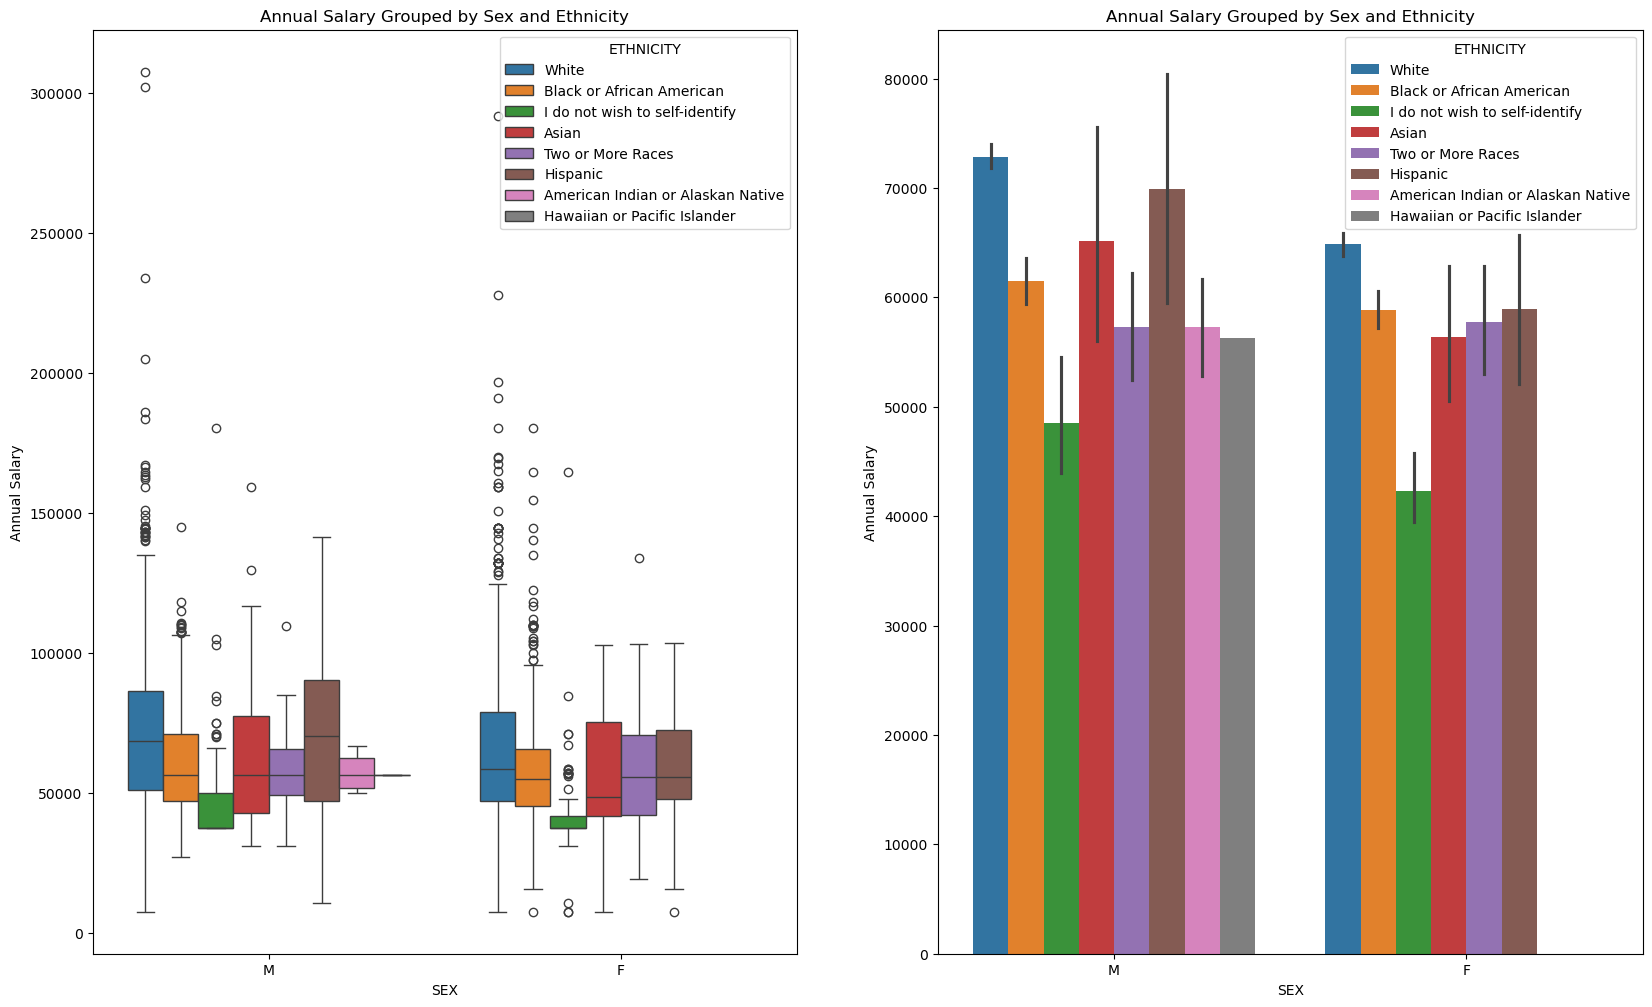

In [5]:
fig, axes = plt.subplots(1,2, figsize=(20,12))

sns.boxplot(df, x='SEX', y='ANNUAL_SALARY', hue='ETHNICITY', ax=axes[0])
axes[0].set_title('Annual Salary Grouped by Sex and Ethnicity')
axes[0].set_xlabel('SEX')
axes[0].set_ylabel('Annual Salary')

sns.barplot(df, x='SEX', y='ANNUAL_SALARY', hue='ETHNICITY', ax=axes[1])
axes[1].set_title('Annual Salary Grouped by Sex and Ethnicity')
axes[1].set_xlabel('SEX')
axes[1].set_ylabel('Annual Salary')

plt.show()

The first thing I wanted to do was get an overall comparison of the average salaries for employees when grouped by both sex and ethnicity. I used both a boxplot and a barchart to give a good look at the averages, as well as the highest numbers. These plots show similar information, with a few interesting insights and differences.

On the similarity side, they both show that employees who refuse to self-identify their ethnicities have the lowest average and overall salaries, for both men and women. They also both show that men in every ethnicity tend to have higher salaries than women of their own ethnicities; the only exception being women of "Two or More Races", which show higher salaries than men of the same group.

An interesting difference between the two plots is the fact that the boxplot shows that hispanic men have a higher interquartile range than white men, even though white men have a higher bar in the barplot. This reveals that the top 25% of hispanic men have higher salaries than the top 25% of white men on average; however, white men have more significantly high individual outliers, which raises the bar of their salaries in the bar chart. This is clearly exemplified in the boxplot, which shows two white men with salaries over $300,000, significantly higher than any other group.

## Examining Correlating Attributes

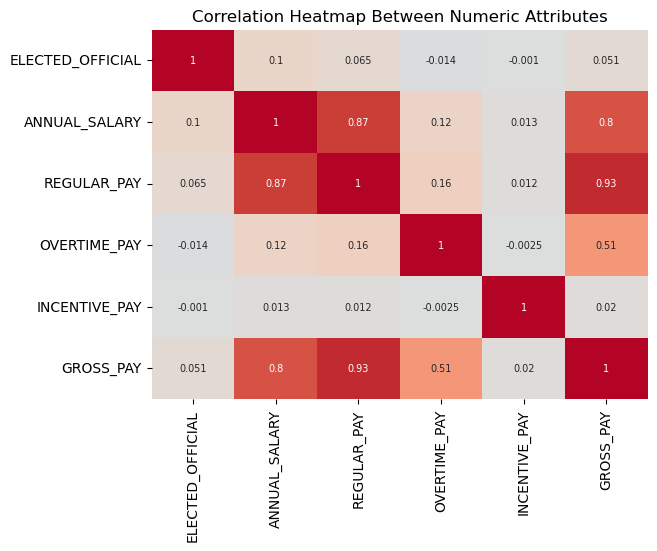

In [6]:
fig, ax = plt.subplots()

sns.heatmap(df.corr(numeric_only=True), 
           vmin=-1, vmax=1, center=0, 
           annot=True, annot_kws={'fontsize': 7}, 
           ax=ax, cbar=False, cmap='coolwarm')
ax.set_title('Correlation Heatmap Between Numeric Attributes')

plt.show()

Since the initial box and bar plots mostly matched up with my initial assumptions about the data, I wanted to see if any numeric attributes correlated with higher salaries. The correlation chart above shows that extra sources of pay, such as "Overtime Pay" and "Incentive Pay" have very low correlations with annual salary. Instead, "Regular Pay" and "Gross Pay" have much stronger positive correlations of 0.87 and 0.8 respectively. These insights dispute any notion that those with higher salaries are being rewarded solely on the basis of hard work. The low overtime and incentive pay correlations show that employee salaries are not necessarily rising along with an employee's overtime hours or outstanding achievements, which would be rewarded in their incentive pay.

It's also important to note that all figures in the data are year-to-date (January to April), except for Annual Salary, which is merely a reporting of the salary figure that the employee is going to receieve during said year. That discrepancy helps explain some of the discrepancy between Annual Salary and both Gross and Regular Pay. But with that being said, the high correlations between those three data points reveals that the employees earning the most money are earning it because those are the salary figures they've been offered, not because they've worked more hours or earned higher incentives.

## Analyzing the Individual Highest Earners for Both Gross and Annual Pay

In [7]:
benchmark = 10000
high_gross = []
for i in range(len(df)):
    if df['GROSS_PAY'][i] > benchmark:
        benchmark = df['GROSS_PAY'][i]
        high_gross.append(df.loc[df.GROSS_PAY == benchmark])

In [8]:
df_high_gross = pd.concat(high_gross, ignore_index=True)

In [9]:
benchmark = 80000
high_salary = []
for i in range(len(df)):
    if df['ANNUAL_SALARY'][i] > benchmark:
        benchmark = df['ANNUAL_SALARY'][i]
        high_salary.append(df.loc[df.ANNUAL_SALARY == benchmark])

In [10]:
df_high_salary = pd.concat(high_salary, ignore_index=True)

C:\Users\abene\AppData\Local\Temp\ipykernel_21088\3237495106.py:8: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(df_high_gross, x='SEX', y='DATE_STARTED', hue='ETHNICITY', join=False, ax=axes[1])
C:\Users\abene\AppData\Local\Temp\ipykernel_21088\3237495106.py:13: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(df_high_salary, x='SEX', y='DATE_STARTED', hue='ETHNICITY', join=False)


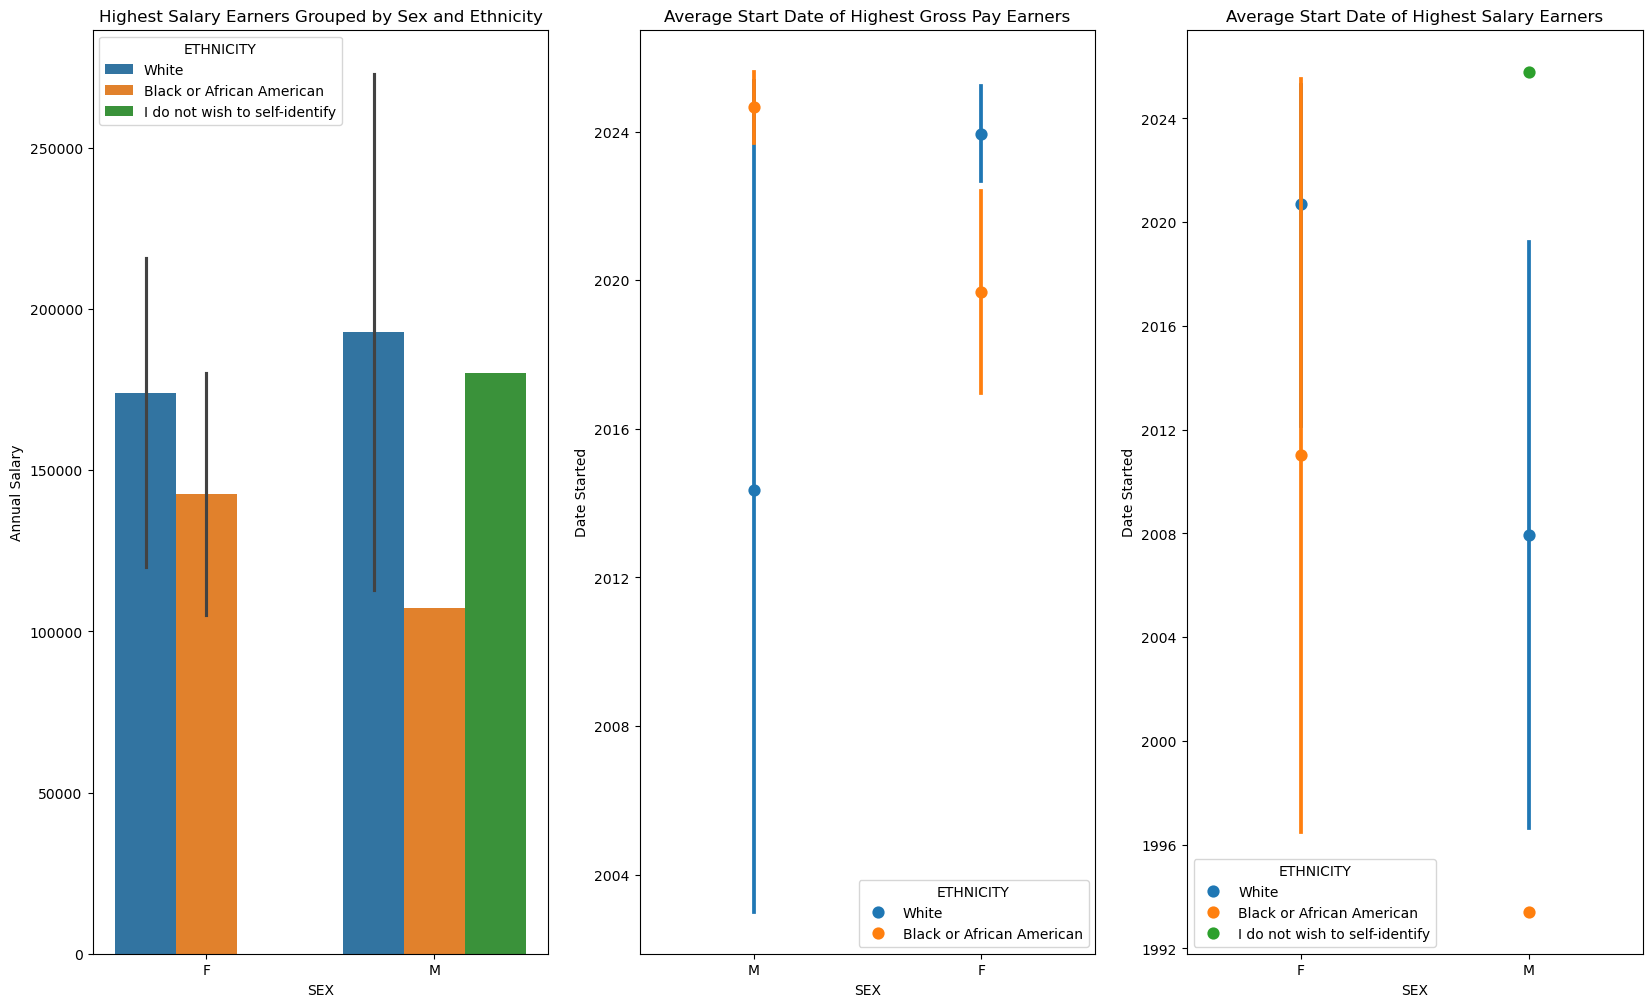

In [11]:
fig, axes = plt.subplots(1,3, figsize=(20,12))

sns.barplot(df_high_salary, x='SEX', y='ANNUAL_SALARY', hue='ETHNICITY', ax=axes[0])
axes[0].set_title('Highest Salary Earners Grouped by Sex and Ethnicity')
axes[0].set_xlabel('SEX')
axes[0].set_ylabel('Annual Salary')

sns.pointplot(df_high_gross, x='SEX', y='DATE_STARTED', hue='ETHNICITY', join=False, ax=axes[1])
axes[1].set_title('Average Start Date of Highest Gross Pay Earners')
axes[1].set_xlabel('SEX')
axes[1].set_ylabel('Date Started')

sns.pointplot(df_high_salary, x='SEX', y='DATE_STARTED', hue='ETHNICITY', join=False)
axes[2].set_title('Average Start Date of Highest Salary Earners')
axes[2].set_xlabel('SEX')
axes[2].set_ylabel('Date Started')

plt.show()

Lastly, I wanted to see what trends I could find among the highest gross pay earners and salary earners. I filtered the datasets to give me the top earners for each category over a certain benchmark, 10,000 USD for gross pay and 80,000 USD for annual salary. When looking at the highest salary earners, I was surprised to see that there was representation of the ethnic group of "I do not wish to self identify", since that was the lowest scoring group when looking at the initial salary data in the overall set. Additionally, I was surprised to see no hispanic individuals represented in the male highest earners, considering that they had the highest interquartile range. This makes sense, however. As mentioned when analyzing the earlier boxplot, hispanic men had the highest average, but they did not have any remarkable outliers. This explains why they would have the most impressive boxplot, yet be underrepresented when looking at individual earners.

My two point plots were made to assess if the highest earners (in both gross and annual pay) showed any patterns regarding their start dates at their respective jobs. When comparing the two plots, it quickly becomes evident that the higher salary earners tend to have started their roles earlier than the higher gross pay workers, which could be due to the latter feeling the need to earn more overtime pay to compensate. This is also evidenced by our earlier correlation heatmap, which showed a 0.51 positive correlation between gross pay and overtime pay.

## Conclusion

Altogether, this data wasn't able to disprove most of the setereotypes and assumptions about salaries in the U.S.A. Among almost every group, men earned more money than women, and white employees earned more than other ethnicities. Even when another ethnicity had higher averages (hispanic men), white men still had enough outliers that made them overrepresented when examining the individual highest earners. This data doesn't prove that sex or ethnicity contribute to disparities in salary earnings, however it does reinforce correlations that are widely assumed about this topic.